# AlphaGenome Tutorial

This notebook demonstrates how to use AlphaGenome for personalized variant effect prediction (VEP) using 1000 Genomes Project data with genvarloader.

**AlphaGenome** is Google DeepMind's unified DNA sequence model that predicts thousands of functional genomic tracks at single base-pair resolution from sequences up to 1Mb.

## Features
- **Multiple modalities**: RNA-seq, ATAC-seq, DNase-seq, CAGE, histone marks, TF binding, contact maps, splicing
- **Official JAX implementation**: Load weights from HuggingFace or Kaggle
- **Personalized VEP**: Compare predictions across individual haplotypes

## Prerequisites

```bash
# Clone and install the official AlphaGenome research repository
git clone https://github.com/google-deepmind/alphagenome_research.git
pip install -e ./alphagenome_research

# For genvarloader
pip install genvarloader
```

**Note**: Requires JAX with GPU support. Tested on NVIDIA H100 GPUs.

## Setup

In [68]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import warnings
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")

import pandas as pd
import polars as pl
import numpy as np
import genvarloader as gvl
import pooch
from tempfile import TemporaryDirectory
from pathlib import Path
from tqdm.auto import tqdm

import src.utils as utils
import src.GVL as GVL
import src.alphagenome as ag

import matplotlib.pyplot as plt

## 1. Load AlphaGenome Model

AlphaGenome weights can be loaded from:
- **HuggingFace**: `Backend.HUGGINGFACE` (recommended)
- **Kaggle**: `Backend.KAGGLE`
- **Local path**: `Backend.LOCAL`

In [11]:
# Load model from HuggingFace (downloads weights on first run)
model = ag.load_model(
    backend=ag.Backend.HUGGINGFACE,
    fold="fold_0"  # Use all cross-validation folds for best performance
)

Loading AlphaGenome from HuggingFace (fold=fold_0)...


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/home/schilder/.conda/envs/alphagenome/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/home/schilder/.conda/envs/alphagenome/lib/python3.12/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


Model loaded successfully.


In [ ]:
# View available output modalities
print("Available modalities:\n")
print(f"{'Modality':<20} {'Tracks':>8}  Description")
print("-" * 70)
for name, info in ag.OUTPUT_MODALITIES.items():
    print(f"{name:<20} {info['tracks']:>8}  {info['description']}")

print(f"\n{'Total tracks:':<20} {ag.get_total_tracks():>8}")

Available modalities:

Modality               Tracks  Description
----------------------------------------------------------------------
atac                      256  Chromatin accessibility (ATAC-seq)
dnase                     384  DNase-seq
procap                    128  Transcription initiation (PRO-cap)
cage                      640  5' cap RNA (CAGE)
rnaseq                    768  RNA expression
chip_tf                  1664  Transcription factor binding
chip_histone             1152  Histone modifications
contact_maps               28  3D chromatin contacts
splice_sites                5  Splice site classification
splice_junctions          734  Junction read counts
splice_site_usage         734  Splice site usage fraction

Total tracks:            6493


## 2. Quick Test with Random Sequences

First, let's test the model with random sequences to verify everything works.

In [ ]:
# Generate random REF and ALT sequences
# AlphaGenome supports up to 1Mb sequences, but we'll use 512kb for this test
seq_length = ag.SEQUENCE_LENGTH_500KB  # 524,288 bp

seq_ref = utils.random_seqs(N=1, L=seq_length, as_str=True)[0]
seq_alt = utils.get_mutated_sequence(seq_ref, mutations=1)  # 1 random mutation

print(f"Sequence length: {len(seq_ref):,} bp")
print(f"REF sequence (first 50bp): {seq_ref[:50]}...")
print(f"ALT sequence (first 50bp): {seq_alt[:50]}...")

Mutating 1 sequence positions
Sequence length: 524,288 bp
REF sequence (first 50bp): TTTCATACACGATATCTTTCGCCGTTGTGGTGAGGATATTCAAGAGAGGA...
ALT sequence (first 50bp): TTTCATACACGATATCTTTCGCCGTTGTGGTGAGGATATTCAAGAGAGGA...


In [6]:
# Score a subset of modalities for speed
test_modalities = ["rnaseq", "atac", "dnase"]

# Score REF sequence
trks_ref = ag.score_sequence(
    seq=seq_ref,
    model=model,
    modalities=test_modalities
)

print("REF track shapes:")
for name, trk in trks_ref.items():
    print(f"  {name}: {trk.shape}")

E0309 21:25:51.198115  429653 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0309 21:25:58.683190  429675 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


REF track shapes:
  rnaseq: (524288, 667)
  atac: (524288, 167)
  dnase: (524288, 305)


In [16]:
# Run full VEP pipeline (REF vs ALT comparison)
vep_results = ag.run_vep(
    seq_ref=seq_ref,
    seq_alt=seq_alt,
    model=model,
    modalities=test_modalities,
    scoring_method="both",  # Compute both LFC and COVR
    aggregate_modalities=True,
    verbose=True
)

# Display aggregated results
print("\nAggregated VEP metrics across modalities:")
print("\nAlphaGenome-style (LFC = Log Fold Change):")
for metric in ["LFC_mean", "LFC_abs_mean", "LFC_max"]:
    if metric in vep_results["aggregated"]:
        print(f"  {metric}: {vep_results['aggregated'][metric]:.6f}")

print("\nFlashzoi-style (COVR):")
for metric in ["delta_abs_mean", "COVR"]:
    if metric in vep_results["aggregated"]:
        print(f"  {metric}: {vep_results['aggregated'][metric]:.6f}")

Scoring WT sequence...
Scoring MUT sequence...
Computing VEP metrics...

Aggregated VEP metrics across modalities:

AlphaGenome-style (LFC = Log Fold Change):
  LFC_mean: 0.000119
  LFC_abs_mean: 0.001581
  LFC_max: 1.122205

Flashzoi-style (COVR):
  delta_abs_mean: 0.000047
  COVR: 3.171054


In [17]:
# Display per-modality results
print("Per-modality VEP metrics:\n")
for modality, metrics in vep_results["per_modality"].items():
    print(f"{modality}:")
    lfc = metrics.get("LFC_abs_mean")
    covr = metrics.get("COVR")
    if lfc is not None:
        print(f"  LFC (abs mean): {float(lfc):.6f}")
    if covr is not None:
        print(f"  COVR:           {float(covr):.6f}")
    print()

Per-modality VEP metrics:

atac:
  LFC (abs mean): 0.001681
  COVR:           5.371947

rnaseq:
  LFC (abs mean): 0.001209
  COVR:           1.065461

dnase:
  LFC (abs mean): 0.001853
  COVR:           3.075756



## 3. Load 1000 Genomes Data with GenVarLoader

Now let's use real genetic variation data from the 1000 Genomes Project.

In [2]:
# Download example data (chromosome 22)
# Reference genome (gzip-compressed, needs bgzip for indexing)
import subprocess, gzip, shutil

reference_gz = pooch.retrieve(
    url="https://ftp.ensembl.org/pub/release-112/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.22.fa.gz",
    known_hash="sha256:974f97ac8ef7ffae971b63b47608feda327403be40c27e391ee4a1a78b800df5",
    progressbar=True,
)

# Decompress gzip and re-compress with bgzip (required by pyfaidx/genvarloader)
reference = reference_gz.replace(".fa.gz", ".fa.bgz")
if not os.path.exists(reference):
    reference_fa = reference_gz.replace(".fa.gz", ".fa")
    if not os.path.exists(reference_fa):
        print("Decompressing gzip FASTA...")
        with gzip.open(reference_gz, 'rb') as f_in, open(reference_fa, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("Re-compressing with bgzip...")
    subprocess.run(["bgzip", "-c", reference_fa], stdout=open(reference, 'wb'), check=True)
    print("Indexing with samtools...")
    subprocess.run(["samtools", "faidx", reference], check=True)
    os.remove(reference_fa)  # Clean up uncompressed file
    print("Done.")
else:
    # Ensure index exists
    if not os.path.exists(reference + ".fai"):
        subprocess.run(["samtools", "faidx", reference], check=True)

print(f"Reference: {reference}")

# 1000 Genomes variants (PLINK2 format)
variants = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pgen",
    known_hash="md5:31aba970e35f816701b2b99118dfc2aa",
    progressbar=True,
    fname="1kGP.chr22.pgen",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.psam",
    known_hash="md5:eefa7aad5acffe62bf41df0a4600129c",
    progressbar=True,
    fname="1kGP.chr22.psam",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pvar",
    known_hash="md5:5f922af91c1a2f6822e2f1bb4469d12b",
    progressbar=True,
    fname="1kGP.chr22.pvar",
)
print(f"Variants: {variants}")

Reference: /home/schilder/.cache/pooch/edfb24b9fee5f1060c26e092a696e447-Homo_sapiens.GRCh38.dna.chromosome.22.fa.bgz
Variants: /home/schilder/.cache/pooch/1kGP.chr22.pgen


In [3]:
# Define genomic regions of interest
# For AlphaGenome, we can use longer sequences (up to 1Mb)
# Here we'll use 512kb windows for demonstration

window_size = ag.SEQUENCE_LENGTH_500KB    

# Example regions on chr22 (can be replaced with your regions of interest)
regions = pl.DataFrame({
    "chrom": ["22", "22", "22"],
    "chromStart": [20000000, 25000000, 30000000],
    "chromEnd": [20000000 + window_size, 25000000 + window_size, 30000000 + window_size],
    "name": ["region_1", "region_2", "region_3"]
})

print(f"Regions (window size = {window_size:,} bp):")
print(regions)

Regions (window size = 524,288 bp):
shape: (3, 4)
┌───────┬────────────┬──────────┬──────────┐
│ chrom ┆ chromStart ┆ chromEnd ┆ name     │
│ ---   ┆ ---        ┆ ---      ┆ ---      │
│ str   ┆ i64        ┆ i64      ┆ str      │
╞═══════╪════════════╪══════════╪══════════╡
│ 22    ┆ 20000000   ┆ 20524288 ┆ region_1 │
│ 22    ┆ 25000000   ┆ 25524288 ┆ region_2 │
│ 22    ┆ 30000000   ┆ 30524288 ┆ region_3 │
└───────┴────────────┴──────────┴──────────┘


In [4]:
# Create GVL dataset
ds_path = TemporaryDirectory(suffix=".gvl").name

gvl.write(
    path=ds_path,
    bed=regions,
    variants=variants,
    overwrite=True,
)

print(f"GVL dataset created at: {ds_path}")

2026-03-09 21:27:24.053 | INFO     | genvarloader._dataset._write:write:106 - Writing dataset to /home/schilder/.cache/tmp/tmpevstfiou.gvl
2026-03-09 21:27:24.114 | INFO     | genoray._pgen:_load_index:1125 - Loading genoray index.
2026-03-09 21:27:24.214 | INFO     | genvarloader._dataset._write:write:178 - Using 451 samples.
2026-03-09 21:27:24.215 | INFO     | genvarloader._dataset._write:write:183 - Writing genotypes.


  0%|          | 0/3 [00:00<?, ? region/s]

0rows [00:00, ?rows/s]

2026-03-09 21:27:25.490 | INFO     | genvarloader._dataset._write:write:214 - Finished writing.


GVL dataset created at: /home/schilder/.cache/tmp/tmpevstfiou.gvl


In [113]:
# Open the dataset with haplotype sequences
with_len= window_size#"fixed"
ds = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("haplotypes")
    .with_len(with_len)
)

# Also open with reference sequences (for comparison)
ds_ref = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("reference")
    .with_len(with_len)
)

print(f"Number of samples: {len(ds.samples)}")
print(f"Number of regions: {len(ds.regions)}")
print(f"Ploidy: {ds.ploidy}")

2026-03-09 21:28:07.048 | INFO     | genvarloader._dataset._reconstruct:from_path:253 - Loading variant data.
2026-03-09 21:28:07.983 | INFO     | genvarloader._dataset._impl:open:275 - Opened dataset:
GVL store at /home/schilder/.cache/tmp/tmpevstfiou.gvl
Is subset: False
# of regions: 3
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference haplotypes annotated [variants]
Active tracks: None
Tracks available: None

2026-03-09 21:28:08.016 | INFO     | genvarloader._dataset._reconstruct:from_path:253 - Loading variant data.
2026-03-09 21:28:08.979 | INFO     | genvarloader._dataset._impl:open:275 - Opened dataset:
GVL store at /home/schilder/.cache/tmp/tmpevstfiou.gvl
Is subset: False
# of regions: 3
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference haplotypes annotated [variants]
Active tracks: None
Tracks available: None



Number of samples: 451
Number of regions: 3
Ploidy: 2


## 4. Define Clinical Variants (Sites)

For personalized VEP, we need to define variants of interest to test.

In [114]:
# Define example clinical variants on chr22
# These could come from ClinVar, GWAS, or other sources
# Positions are near the center of each region so they remain within
# the window even at small window sizes (e.g. 2kb).
sites = pl.DataFrame({
    "CHROM": ["22", "22", "22"],
    "POS": [20000000 + window_size // 2,
            25000000 + window_size // 2,
            30000000 + window_size // 2],
    "REF": ["A", "G", "C"],
    "ALT": ["G", "A", "T"],
    "gene": ["GENE1", "GENE2", "GENE3"]  # Optional metadata
})

print("Clinical variants to test:")
print(sites)

Clinical variants to test:
shape: (3, 5)
┌───────┬──────────┬─────┬─────┬───────┐
│ CHROM ┆ POS      ┆ REF ┆ ALT ┆ gene  │
│ ---   ┆ ---      ┆ --- ┆ --- ┆ ---   │
│ str   ┆ i64      ┆ str ┆ str ┆ str   │
╞═══════╪══════════╪═════╪═════╪═══════╡
│ 22    ┆ 20262144 ┆ A   ┆ G   ┆ GENE1 │
│ 22    ┆ 25262144 ┆ G   ┆ A   ┆ GENE2 │
│ 22    ┆ 30262144 ┆ C   ┆ T   ┆ GENE3 │
└───────┴──────────┴─────┴─────┴───────┘


In [115]:
# Create DatasetWithSites for variant injection
site_ds = gvl.DatasetWithSites(ds, sites)
site_ds_ref = gvl.DatasetWithSites(ds_ref, sites)

# Add site names for tracking
GVL.add_site_name(site_ds)

print(f"Sites dataset created with {len(site_ds.rows)} site-region pairs")
print(site_ds.rows)

Sites dataset created with 3 site-region pairs
shape: (3, 11)
┌────────────┬───────┬────────────┬──────────┬───┬─────┬───────┬──────────┬────────────────────────┐
│ region_idx ┆ chrom ┆ chromStart ┆ chromEnd ┆ … ┆ ALT ┆ gene  ┆ POS0     ┆ site_name              │
│ ---        ┆ ---   ┆ ---        ┆ ---      ┆   ┆ --- ┆ ---   ┆ ---      ┆ ---                    │
│ u32        ┆ cat   ┆ i64        ┆ i64      ┆   ┆ str ┆ str   ┆ i64      ┆ str                    │
╞════════════╪═══════╪════════════╪══════════╪═══╪═════╪═══════╪══════════╪════════════════════════╡
│ 0          ┆ 22    ┆ 20000000   ┆ 20524288 ┆ … ┆ G   ┆ GENE1 ┆ 20262143 ┆ chr22:20000000-2052428 │
│            ┆       ┆            ┆          ┆   ┆     ┆       ┆          ┆ 8_A_G                  │
│ 1          ┆ 22    ┆ 25000000   ┆ 25524288 ┆ … ┆ A   ┆ GENE2 ┆ 25262143 ┆ chr22:25000000-2552428 │
│            ┆       ┆            ┆          ┆   ┆     ┆       ┆          ┆ 8_G_A                  │
│ 2          ┆ 22    ┆ 300000

## 5. Run Personalized VEP Across Haplotypes

Now we'll run AlphaGenome VEP for each individual's haplotypes, comparing their REF sequence to the sequence with the clinical variant injected.

In [59]:
# Configuration
max_samples = 10  # Limit samples for demo (set to None for all)
test_modalities = ["rnaseq", "atac"]  # Use subset of modalities for speed

# Select samples
sample_names = ds.samples[:max_samples] if max_samples else ds.samples
print(f"Running VEP for {len(sample_names)} samples")

Running VEP for 10 samples


In [60]:
# Filter to valid site-region pairs
region_to_site = GVL.filter_region_to_site(site_ds.rows)
print(f"Processing {len(region_to_site)} site-region pairs")

Sites before filter_region_to_site:  (3, 11)
Sites after site_filters:  (3, 12)
Sites after region_idx==site_idx filter:  (3, 12)
Processing 3 site-region pairs


In [61]:
if "model" not in locals():
    model = ag.load_model()

In [12]:
# Run VEP for each site x haplotype combination
results_df = ag.run_vep_across_sites(
    site_ds=site_ds,
    row_indices=region_to_site["index"].to_list(),
    sample_names=sample_names,
    model=model,
    modalities=test_modalities,
    scoring_method="both",
    per_modality_metrics=["LFC_abs_mean", "COVR"],
    verbose=True,
)
print(f"Results shape: {results_df.shape}")
results_df.head()

Processing sites:   0%|          | 0/3 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 6. Analyze Inter-Haplotype Variation

Let's analyze how VEP scores vary across individuals and haplotypes.

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics by site
site_summary = results_df.groupby("site").agg({
    "agg_LFC_abs_mean": ["mean", "std", "min", "max"],
    "agg_COVR": ["mean", "std", "min", "max"]
}).round(6)

print("Summary statistics by site:")
site_summary

Summary statistics by site:


agg_LFC_abs_mean                                \
                                        mean       std       min       max   
site                                                                         
chr22:20000000-20524288_A_G         0.001396  0.000016  0.001370  0.001432   
chr22:25000000-25524288_G_A         0.000000  0.000000  0.000000  0.000000   
chr22:30000000-30524288_C_T         0.001313  0.000015  0.001288  0.001346   

                             agg_COVR                                
                                 mean       std       min       max  
site                                                                 
chr22:20000000-20524288_A_G  6.716180  0.017829  6.684863  6.747714  
chr22:25000000-25524288_G_A  0.000000  0.000000  0.000000  0.000000  
chr22:30000000-30524288_C_T  3.091004  0.117050  2.819502  3.292584

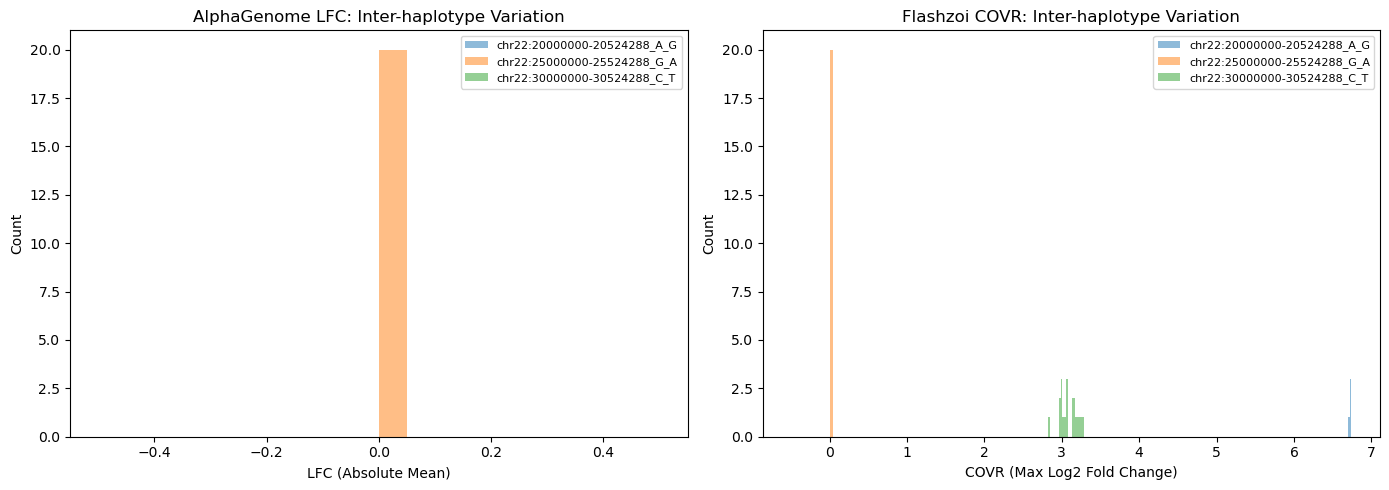

In [81]:
# Plot distribution of VEP scores across haplotypes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LFC (AlphaGenome-style)
ax = axes[0]
for site in results_df["site"].unique():
    site_data = results_df[results_df["site"] == site]["agg_LFC_abs_mean"]
    ax.hist(site_data, alpha=0.5, label=site[:30], bins=20)
ax.set_xlabel("LFC (Absolute Mean)")
ax.set_ylabel("Count")
ax.set_title("AlphaGenome LFC: Inter-haplotype Variation")
ax.legend(fontsize=8)

# COVR (Flashzoi-style)
ax = axes[1]
for site in results_df["site"].unique():
    site_data = results_df[results_df["site"] == site]["agg_COVR"]
    ax.hist(site_data, alpha=0.5, label=site[:30], bins=20)
ax.set_xlabel("COVR (Max Log2 Fold Change)")
ax.set_ylabel("Count")
ax.set_title("Flashzoi COVR: Inter-haplotype Variation")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

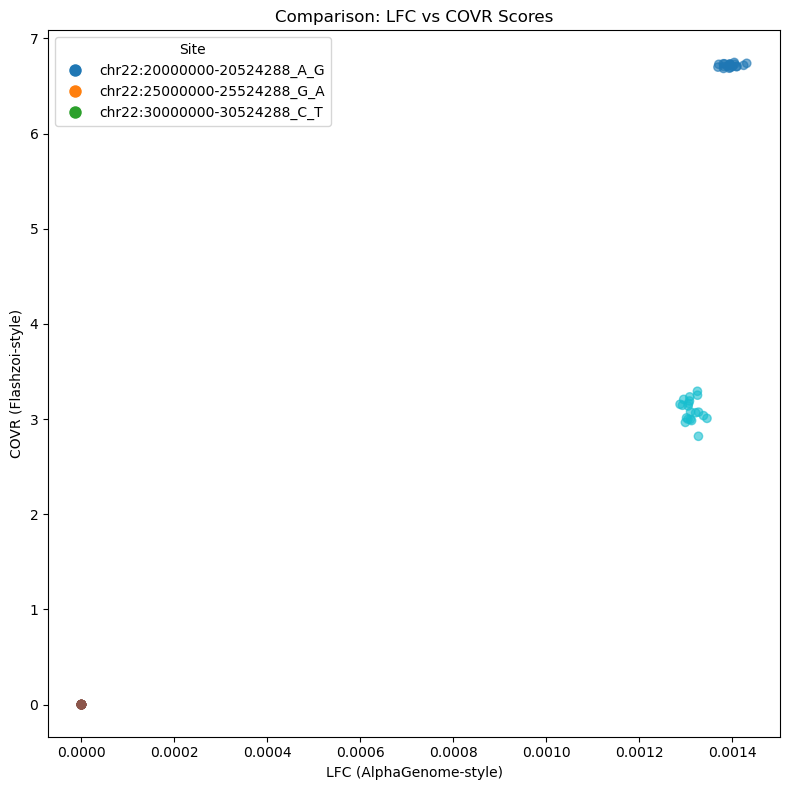

In [82]:
# Compare LFC vs COVR scores
fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(
    results_df["agg_LFC_abs_mean"],
    results_df["agg_COVR"],
    c=results_df["site"].astype("category").cat.codes,
    alpha=0.6,
    cmap="tab10"
)

ax.set_xlabel("LFC (AlphaGenome-style)")
ax.set_ylabel("COVR (Flashzoi-style)")
ax.set_title("Comparison: LFC vs COVR Scores")

handles = [plt.Line2D([0], [0], marker='o', color='w', 
           markerfacecolor=plt.cm.tab10(i), markersize=10, label=site[:30])
           for i, site in enumerate(results_df["site"].unique())]
ax.legend(handles=handles, title="Site")

plt.tight_layout()
plt.show()

## 7. Compare with Reference

Let's also run VEP on the reference genome to establish a baseline.

In [85]:
# Run VEP for reference genome at each site
ref_df = ag.run_vep_across_sites(
    site_ds=site_ds_ref,
    row_indices=region_to_site["index"].to_list()[:3],
    sample_names=[0],
    model=model,
    modalities=test_modalities,
    scoring_method="both",
    per_modality_metrics=["LFC_abs_mean", "COVR"],
    verbose=True,
)
print("Reference VEP scores:")
ref_df

Processing sites:   0%|          | 0/3 [00:00<?, ?it/s]


Processed 6 haplotype-site pairs
Reference VEP scores:


,site,sample,ploid,agg_LFC_mean,agg_LFC_abs_mean,agg_LFC_max,agg_delta_mean,agg_delta_abs_mean,agg_COVR,atac_LFC_abs_mean,atac_COVR,rnaseq_LFC_abs_mean,rnaseq_COVR
0,chr22:20000000-20524288_A_G,0,0,0.000043,0.001371,0.924125,-4.850489e-06,0.000103,6.728110,0.001631,12.793577,0.001112,0.662644
1,chr22:20000000-20524288_A_G,0,1,0.000017,0.001410,0.926557,1.121922e-06,0.000102,6.702656,0.001639,12.837136,0.001180,0.568176
2,chr22:25000000-25524288_G_A,0,0,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,chr22:25000000-25524288_G_A,0,1,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,chr22:30000000-30524288_C_T,0,0,-0.000006,0.001339,0.651788,-2.911496e-06,0.000092,3.036696,0.001593,5.528679,0.001084,0.544712
5,chr22:30000000-30524288_C_T,0,1,-0.000035,0.001288,0.641543,-8.076460e-07,0.000092,3.155887,0.001588,5.812263,0.000988,0.499512


## 8. Save Results

In [86]:
# Save results to CSV
output_dir = Path("results/alphagenome")
output_dir.mkdir(parents=True, exist_ok=True)

# Combine all results
full_results = pd.concat([results_df, ref_df], ignore_index=True)
full_results.to_csv(output_dir / "alphagenome_vep_results.csv", index=False)

print(f"Results saved to {output_dir / 'alphagenome_vep_results.csv'}")
print(f"Total records: {len(full_results)}")

Results saved to results/alphagenome/alphagenome_vep_results.csv
Total records: 66


## 9. Track Visualization

AlphaGenome provides native visualization tools for genomic tracks. Our wrapper in `src.alphagenome` adds:

- **`plot_variant_effect()`** — REF vs ALT overlay for a single individual (uses AlphaGenome's `OverlaidTracks`)
- **`plot_tracks()`** — Single-prediction track visualization
- **`plot_population_variant_effect()`** — Population-level REF vs ALT with mean + CI bands. Uses **datashader** by default for scalable rendering of many individuals, falling back to matplotlib.
- **`make_track_data()`** — Bridge raw numpy arrays to AlphaGenome's `TrackData` objects
- **`aggregate_tracks()`** / **`aggregate_tracks_with_ci()`** — Aggregate across individuals before plotting

### 9a. Single-individual: WT vs MUT track overlay

Use `plot_variant_effect()` with raw model output objects to compare REF and ALT predictions for one individual.

In [14]:
# Pick one site and one individual for the single-individual demo
row_idx = region_to_site["index"].to_list()[0]
modalities_viz = ["rnaseq", "atac"]

result_single = ag.score_site_haplotypes(
    site_ds, row_idx, [sample_names[0]], model,
    modalities=modalities_viz, max_haplotypes=1)

site_name = result_single["site_name"]
coords = result_single["coords"]
# Extract single-haplotype tracks (index 0 from the stacked arrays)
trks_wt_single = {m: arr[0] for m, arr in result_single["wt_tracks"].items()}
trks_mut_single = {m: arr[0] for m, arr in result_single["mut_tracks"].items()}

print(f"Site: {site_name}")
print(f"Sample: {sample_names[0]}")
for mod, arr in trks_wt_single.items():
    print(f"  {mod}: {arr.shape}")

Scoring haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Site: chr22:20000000-20524288_A_G
Sample: HG00096
  rnaseq: (524288, 667)
  atac: (524288, 167)


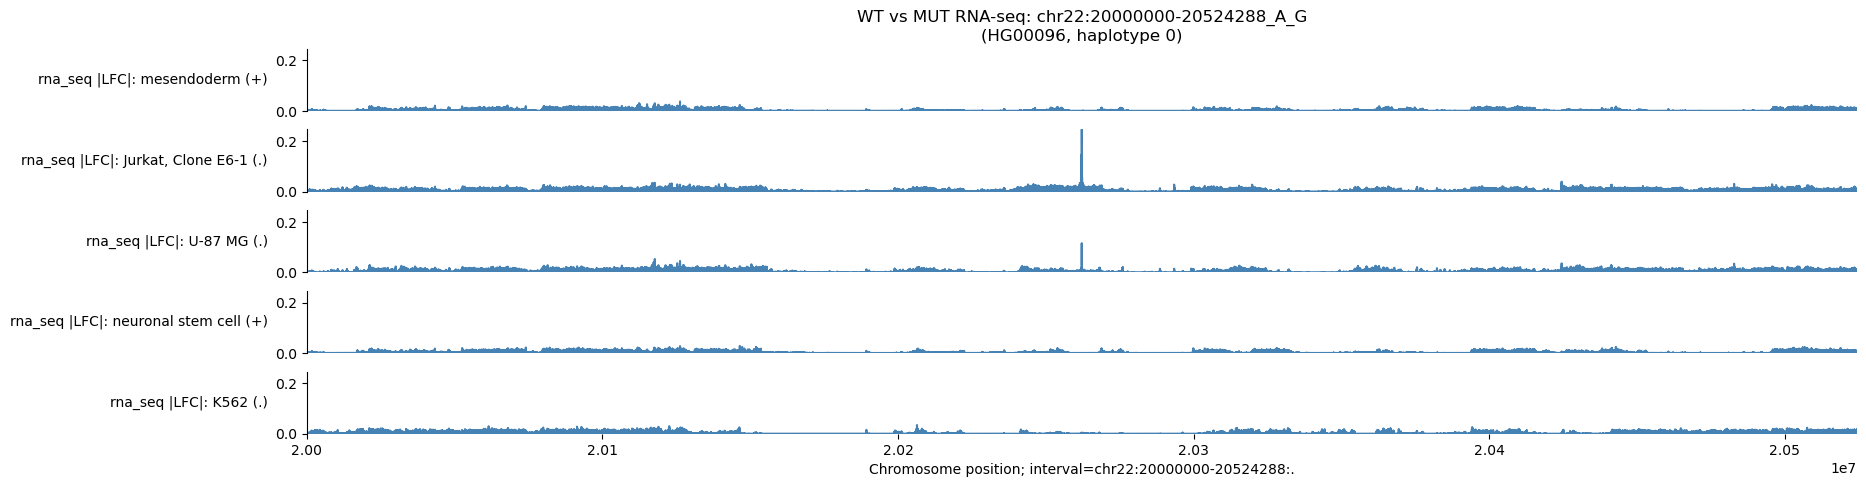

In [69]:
# Plot WT vs MUT for RNA-seq tracks
# WT = wild-type haplotype (without injected variant)
# MUT = mutant haplotype (with injected variant)

wt_td = ag.make_track_data(
    trks_wt_single["rnaseq"], coords["chrom"], coords["start"], coords["end"])
mut_td = ag.make_track_data(
    trks_mut_single["rnaseq"], coords["chrom"], coords["start"], coords["end"])

fig = ag.plot_variant_effect(
    wt_output=wt_td,
    mut_output=mut_td,
    modality="rna_seq",
    model=model,          # enables real track metadata labels
    max_tracks=5,
    title=f"WT vs MUT RNA-seq: {site_name}\n({sample_names[0]}, haplotype 0)",
)
plt.show()

### 9b. Population-level: WT vs MUT across individuals (datashader)

Score WT and MUT for multiple individuals, then use `plot_population_variant_effect()` to visualize all traces at once. Datashader rasterizes thousands of individual traces efficiently on the server side, then overlays mean lines and CI bands.

In [ ]:
# Score WT and MUT for multiple individuals at one site
modalities = ['atac']  # None = all modalities

result_pop = ag.score_site_haplotypes(
    site_ds, 
    row_idx=row_idx,  
    model=model,
    modalities=modalities, 
    max_haplotypes=50
    )

# Also score the reference genome (no variants) for baseline comparison
result_ref = ag.score_site_haplotypes(
    site_ds_ref, 
    row_idx=row_idx, 
    sample_names=[0], 
    model=model,
    modalities=modalities, 
    max_haplotypes=1
    )

# Extract per-modality arrays
# result_pop["wt_tracks"] and result_pop["mut_tracks"] are dicts: {modality: (n_haps, positions, tracks)}
# result_ref similarly, but with 1 haplotype
wt_hap = {mod: list(arr) for mod, arr in result_pop["wt_tracks"].items()}
mut_hap = {mod: list(arr) for mod, arr in result_pop["mut_tracks"].items()}
wt_ref = {mod: arr[0] for mod, arr in result_ref["wt_tracks"].items()}
mut_ref = {mod: arr[0] for mod, arr in result_ref["mut_tracks"].items()}

for mod in wt_hap:
    print(f"[{mod}] {len(wt_hap[mod])} haplotypes, shape {wt_hap[mod][0].shape}, REF {wt_ref[mod].shape}")

Scoring haplotypes:   0%|          | 0/100 [00:00<?, ?it/s]

[plot_population_variant_effect] Preparing inputs...
[plot_population_variant_effect] Early crop: center_bp=400
[plot_population_variant_effect] Aligning to ref coords: True
[plot_population_variant_effect] Ranking tracks (show=COVR)...
[plot_population_variant_effect] Selecting top 5/167 tracks, aggregating...
[plot_population_variant_effect] Rendering with backend=datashader...


/home/schilder/projects/VEP_DNA/src/alphagenome.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


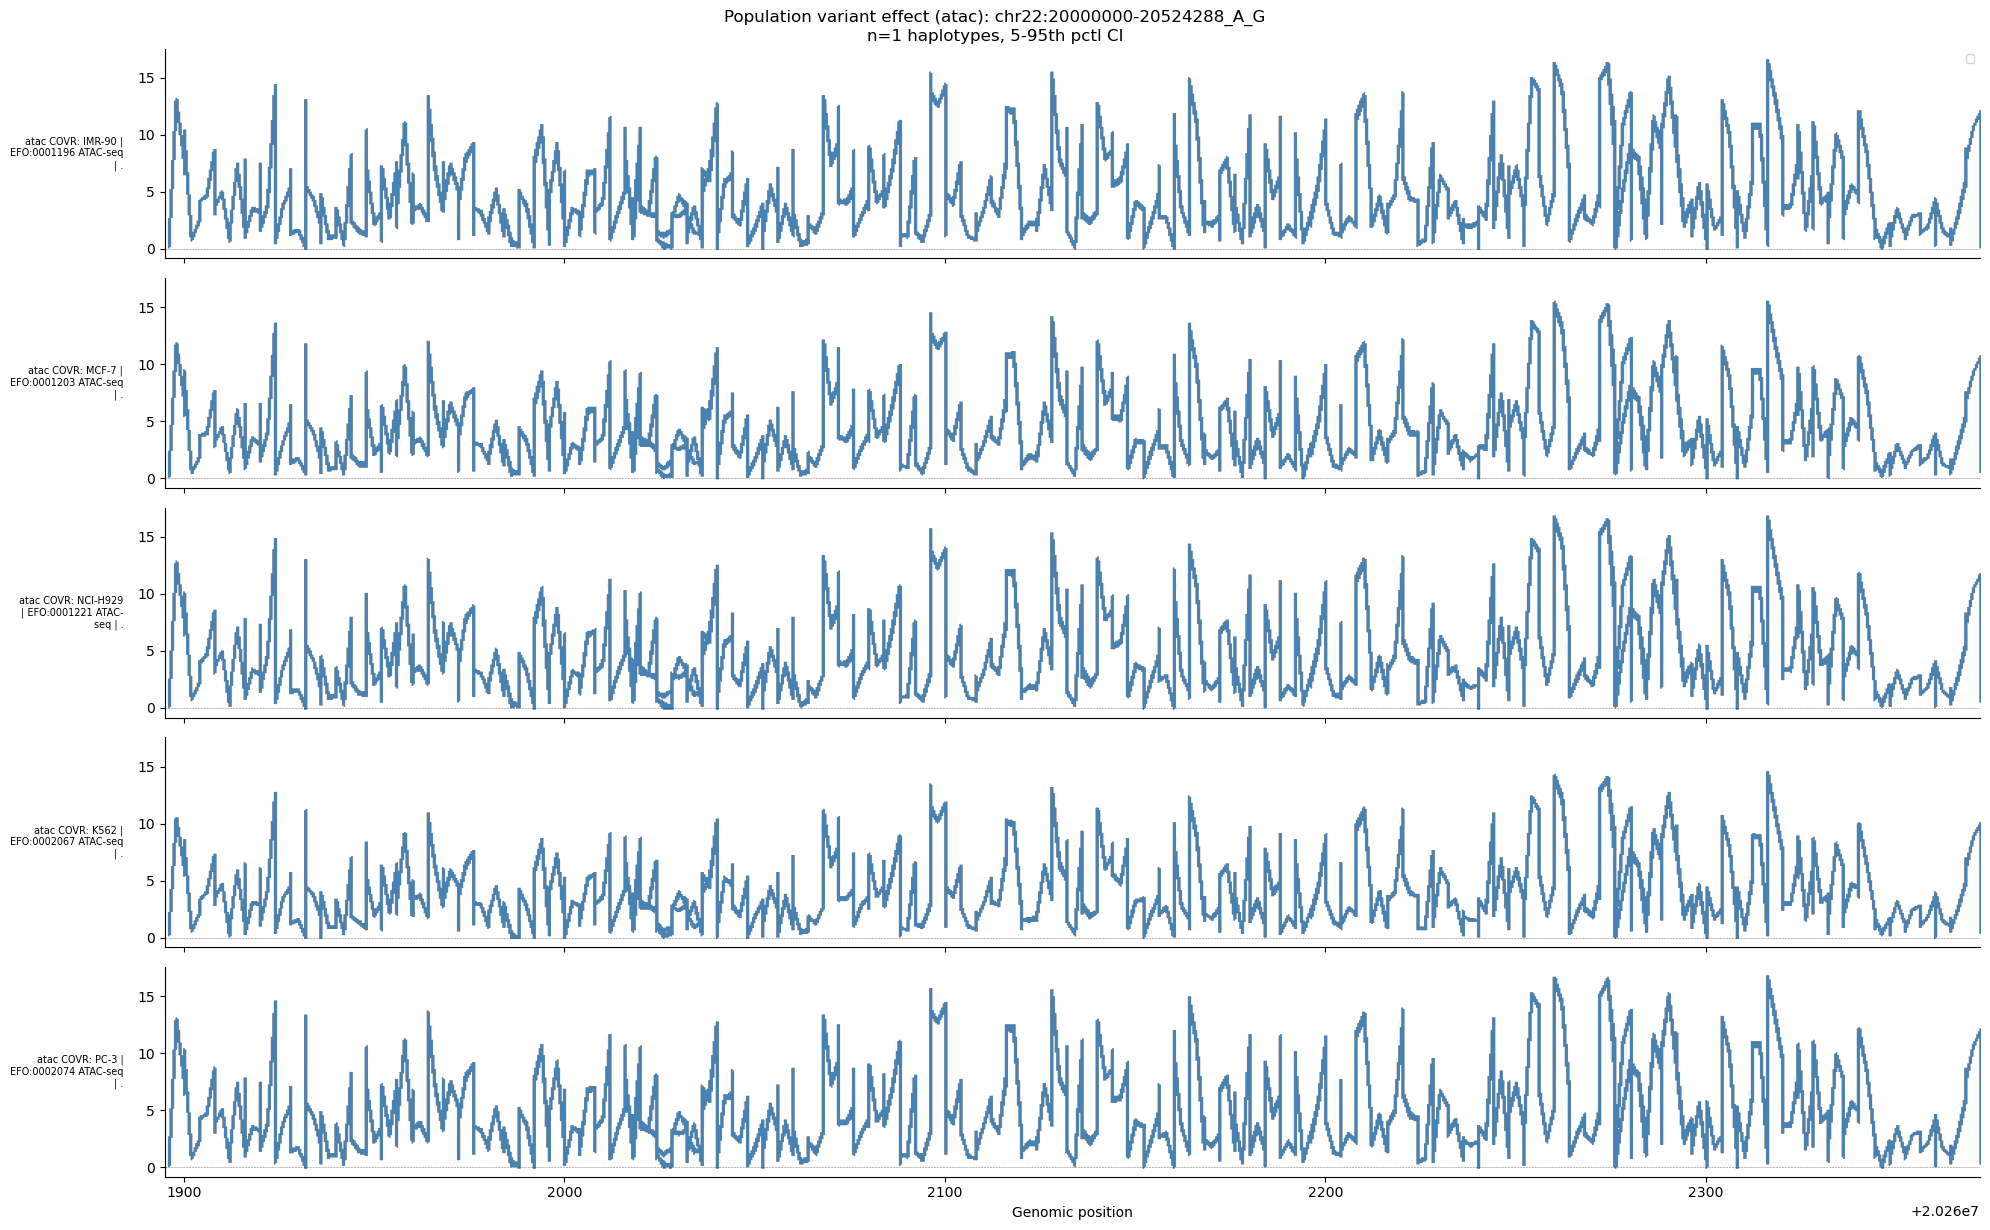

In [67]:
# Population-level visualization: datashader (default) or matplotlib fallback
# - Datashader rasterizes all individual traces server-side (fast, scalable)
# - Mean WT/MUT lines and 5-95th percentile CI bands are overlaid
# - REF baseline (reference genome, no variants) shown as dashed black line
# - backend="auto" uses datashader if installed, else matplotlib
# - Pass model= to auto-label tracks with biosample metadata

fig = ag.plot_population_variant_effect(
    wt_tracks_list=wt_hap,
    mut_tracks_list=mut_hap,
    ref_coords=result_pop["wt_ref_coords"],
    ref_wt=wt_ref,
    ref_mut=mut_ref,

    interval_chrom=coords["chrom"],
    interval_start=coords["start"],
    interval_end=coords["end"],
    show="COVR",
    center_bp=400,
    resolution=1,
    
    modality=modalities,
    model=model,          # enables track metadata labels
    max_tracks=5,         # top 5 tracks by signal
    title=f"Population variant effect ({",".join(modalities)}): {site_name}\n"
          f"n={len(wt_hap)} haplotypes, 5-95th pctl CI",
    backend="auto",       # "datashader", "matplotlib", or "auto"
) 

### 9c. Aggregation helpers

You can also use the aggregation functions directly to compute summary statistics before custom plotting.

In [68]:
# Aggregate tracks across individuals with confidence intervals
wt_agg = ag.aggregate_tracks_with_ci(wt_hap, center="mean", lo_pct=25, hi_pct=75)
mut_agg = ag.aggregate_tracks_with_ci(mut_hap, center="mean", lo_pct=25, hi_pct=75)

print(f"Aggregated shapes:")
print(f"  center: {wt_agg['center'].shape}")
print(f"  lo (25th pctl): {wt_agg['lo'].shape}")
print(f"  hi (75th pctl): {wt_agg['hi'].shape}")

# Quick delta visualization: mean |MUT - WT| across all tracks
delta_mean = np.abs(mut_agg["center"] - wt_agg["center"]).mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 3))
positions = np.linspace(coords["start"], coords["end"], len(delta_mean), endpoint=False)
ax.plot(positions, delta_mean, color="purple", linewidth=0.5, alpha=0.8)
ax.set_xlabel("Genomic position")
ax.set_ylabel("Mean |MUT - WT|")
ax.set_title(f"Mean absolute delta across {modality_pop} tracks: {site_name}")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

ValueError: could not convert string to float: np.str_('atac')

### 9d. Compute variant effects

`compute_variant_effects()` computes per-haplotype effects (COVR, LFC, delta, etc.) from WT and MUT arrays. The result is reused by `most_variable_tracks()`, `top_haplotypes()`, and `plot_top_haplotype_deltas()`.

In [72]:
len(mut_hap['atac'])

20

In [69]:
# Compute variant effects once — reuse for ranking and plotting
# Accepts lists directly (stacking happens internally)
show_metric = "COVR"

effect_hap = ag.compute_variant_effects(
    wt_hap, mut_hap, show=show_metric, as_abs=True)

effect_ref = ag.compute_variant_effects(
    wt_ref, mut_ref, show=show_metric, as_abs=True)

[compute_variant_effects] wt (20, 524288, 167), mut (20, 524288, 167), show='COVR', modality='atac'
[compute_variant_effects] wt (524288, 167), mut (524288, 167), show='COVR', modality='atac'


### 9e. Find most variable tracks → top haplotypes within those tracks

1. `most_variable_tracks()` finds which tracks show the greatest inter-haplotype variability in the variant effect.
2. `top_haplotypes()` then ranks haplotypes *within those selected tracks* — by overall variability (`"variability"`) or deviation from REF (`"ref_deviation"`).

In [104]:
# Step 1: Find the 5 most variable tracks
metric_name = "auc"
center_bp = 2000
top_tracks = ag.most_variable_tracks(
    effect_hap, 
    n=5, metric=metric_name,
    center_bp=center_bp,
)
top_track_idx = top_tracks["indices"]

print(f"Top 5 tracks by {metric_name} of {show_metric}:")
for rank, (idx, score) in enumerate(zip(top_tracks["indices"], top_tracks["scores"])):
    print(f"  {rank+1}. track {idx}: {metric_name} = {score:.6f}")

# Step 2: Find top haplotypes WITHIN those tracks
effect_sub = effect_hap[:, :, top_track_idx]
ref_effect_sub = effect_ref[:, top_track_idx]

top_haplotypes = ag.top_haplotypes(
    effect_sub, 
    n=5,
    rank_by="variability",   # or "ref_deviation"
    scoring="mean",
    center_bp=center_bp,
    ref_effect=ref_effect_sub,
)

print(f"\nTop 5 haplotypes by {show_metric} {top_haplotypes['rank_by']} (within top tracks):")
for rank, (idx, score) in enumerate(zip(top_haplotypes["indices"], top_haplotypes["scores"])):
    sample_idx = idx // 2
    ploid = idx % 2
    sample = sample_names[sample_idx] if sample_idx < len(sample_names) else f"sample_{sample_idx}"
    print(f"  {rank+1}. haplotype {idx} ({sample}, ploid {ploid}): score = {score:.4f}")

Top 5 tracks by auc of COVR:
  1. track 68: auc = 123.238594
  2. track 69: auc = 113.086800
  3. track 1: auc = 110.640732
  4. track 62: auc = 103.478714
  5. track 64: auc = 99.324570

Top 5 haplotypes by COVR variability (within top tracks):
  1. haplotype 4 (HG00099, ploid 0): score = 0.0684
  2. haplotype 10 (HG00102, ploid 0): score = 0.0665
  3. haplotype 17 (HG00106, ploid 1): score = 0.0644
  4. haplotype 16 (HG00106, ploid 0): score = 0.0642
  5. haplotype 15 (HG00105, ploid 1): score = 0.0627


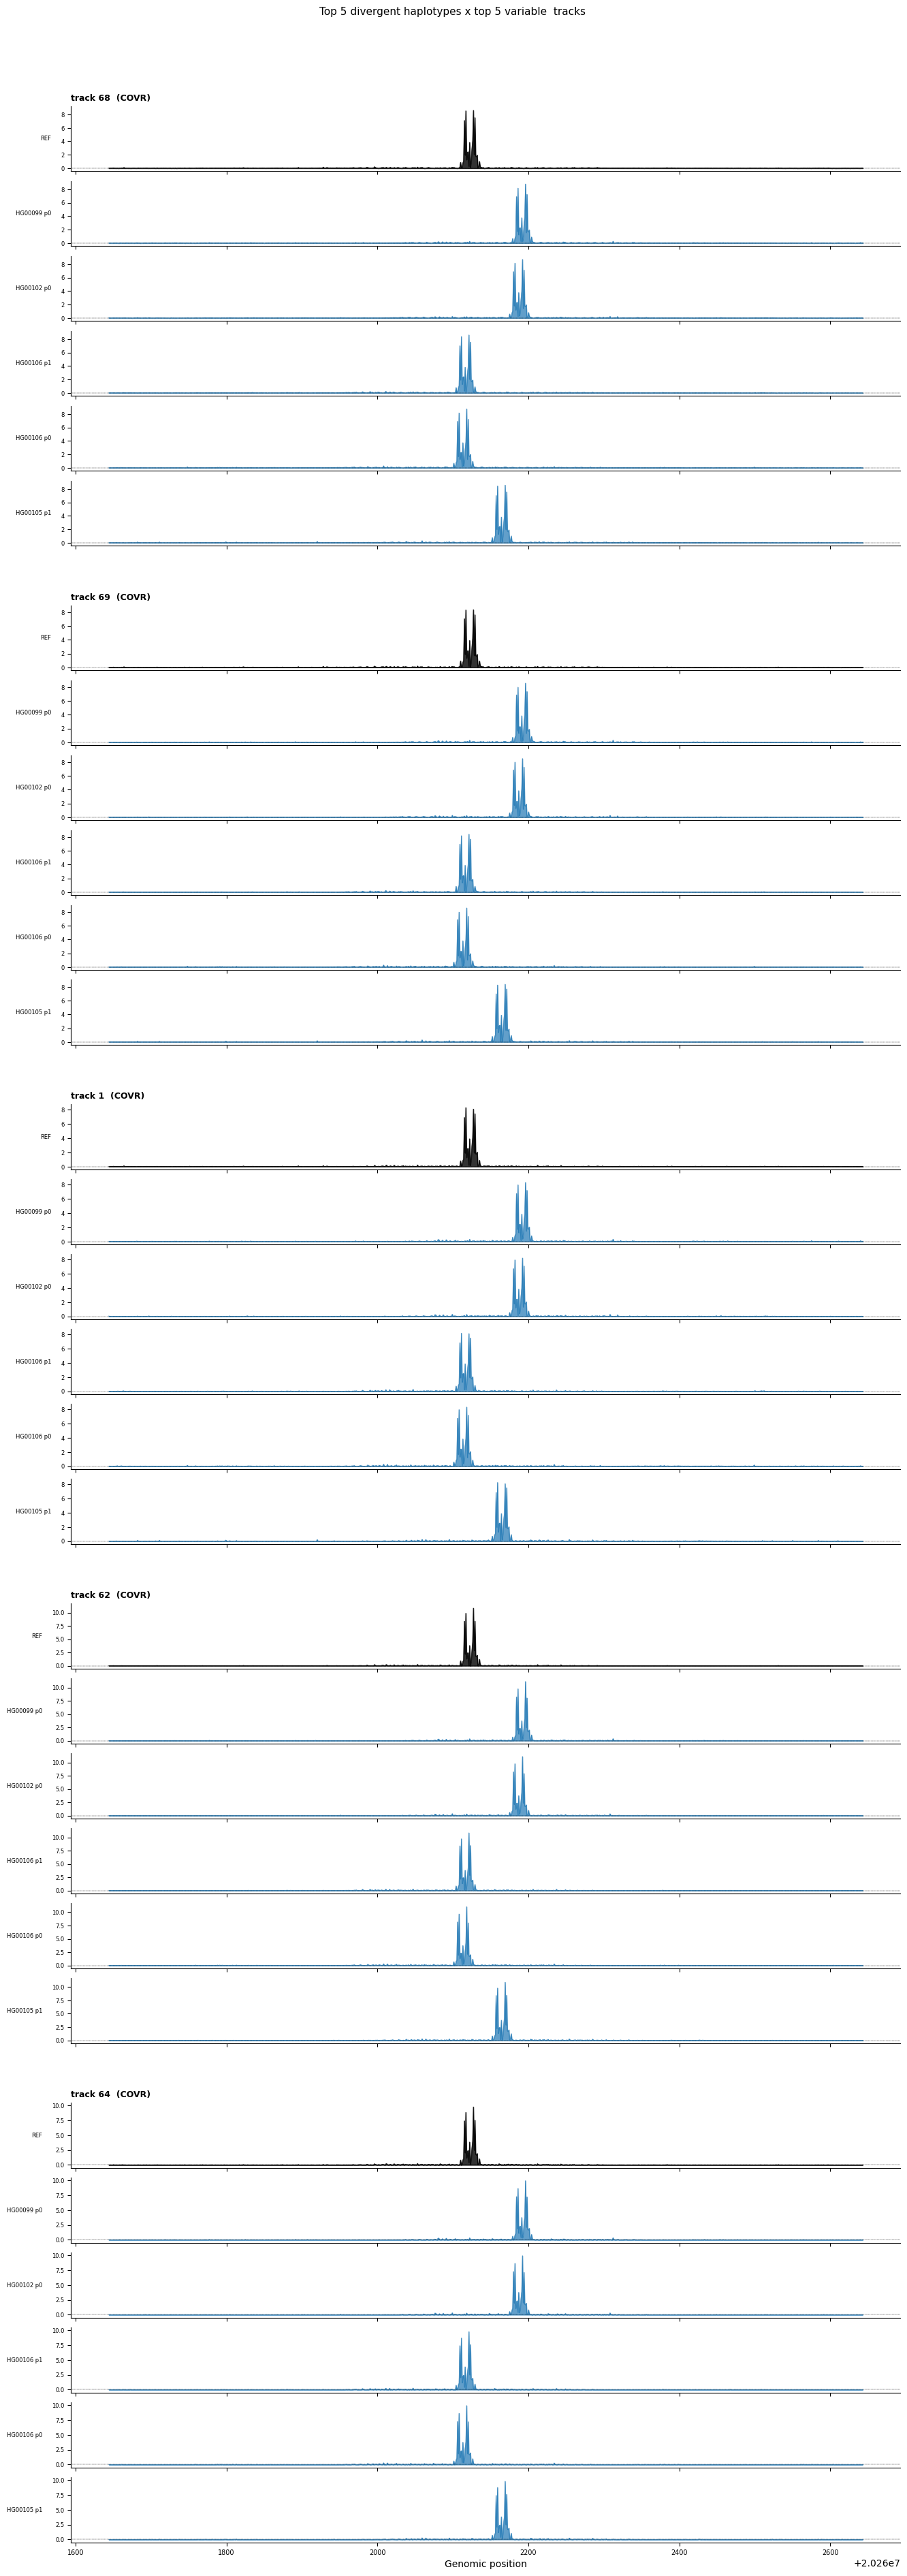

In [105]:
# Plot: top tracks x top haplotypes (both steps done internally too)
# plot_top_haplotype_deltas does the same track→haplotype selection internally,
# or you can pass track_indices from the manual step above.
fig = ag.plot_top_haplotype_deltas(
    effect_hap=effect_hap,
    effect_ref=effect_ref,
    chrom_start=coords["start"],
    chrom_end=coords["end"],
    sample_names=sample_names,
    model=model,                          # enables track metadata labels
    show_label=show_metric,
    center_bp=1000,
    track_indices=top_track_idx,          # use tracks from step 1
    haplotype_indices=top_haplotypes["indices"],  
) 

### 9f. Covariance–HiC contact enrichment

Test whether positions whose variant effects covary across haplotypes
are enriched for predicted 3-D chromatin contacts (HiC).

In [ ]:
# 1) Get the HiC contact map for the reference genome at this site
#    score_interval fetches the reference sequence from the genome FASTA
#    contact_maps shape: (64, 64, 28) — 64 bins, 28 cell-type tracks
hic_preds = ag.score_interval(
    model,
    chromosome=coords["chrom"],
    start=coords["start"],
    end=coords["end"],
    modalities=["contact_maps"],
)
contact_map = hic_preds["contact_maps"]  # (64, 64, 28)
print(f"Contact map shape: {contact_map.shape}")

# 2) Pick a modality from the pre-computed variant effects (cell 9d)
#    effect_hap is a dict: {modality: (n_hap, positions, tracks)}
modality_for_cov = list(effect_hap.keys())[0]
effect_hap_arr = effect_hap[modality_for_cov]  # (n_hap, positions, tracks)
print(f"Effect array [{modality_for_cov}] shape: {effect_hap_arr.shape}")

# 3) Run covariance–HiC enrichment analysis
enrichment = ag.covariance_hic_enrichment(
    effect_hap=effect_hap_arr,
    contact_map=contact_map,
    method="spearman",
    n_quantiles=10,
    min_distance=2,   # skip adjacent bins (trivially correlated)
    plot=True,
)
print(f"\n{enrichment['method'].title()} correlation: "
      f"r={enrichment['correlation']:.4f}, p={enrichment['pvalue']:.2e}")
enrichment["quantile_df"]

## 10. Running AlphaGenome via the VEP Pipeline

AlphaGenome is integrated into the unified `vep_pipeline`, which handles data loading, batching, checkpointing, and result storage automatically. This is the recommended way to run AlphaGenome at scale on 1000 Genomes data.

In [38]:
import src.vep_pipeline as vp
import src.clinvar as cv

# Load ClinVar UTR SNV bed file
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz")
print(f"Total variants in BED: {bed.height}")
print(bed.head())

Extracting ID columns.
Using default maps.
Simplifying annotations.
Total variants in BED: 13771
shape: (5, 49)
┌───────┬────────────┬──────────┬───────────────┬───┬────────┬──────────────┬──────────────┬───────┐
│ chrom ┆ chromStart ┆ chromEnd ┆ name          ┆ … ┆ MeSH_n ┆ CLNSIG_simpl ┆ CLNSIG_super ┆ GENE  │
│ ---   ┆ ---        ┆ ---      ┆ ---           ┆   ┆ ---    ┆ e            ┆ _simple      ┆ ---   │
│ str   ┆ i64        ┆ i64      ┆ str           ┆   ┆ u32    ┆ ---          ┆ ---          ┆ str   │
│       ┆            ┆          ┆               ┆   ┆        ┆ str          ┆ str          ┆       │
╞═══════╪════════════╪══════════╪═══════════════╪═══╪════════╪══════════════╪══════════════╪═══════╡
│ 1     ┆ 1013541    ┆ 1013542  ┆ chr1:1013541- ┆ … ┆ 0      ┆ benign       ┆ benign       ┆ ISG15 │
│       ┆            ┆          ┆ 1013542_T_C   ┆   ┆        ┆              ┆              ┆       │
│ 1     ┆ 1055000    ┆ 1055001  ┆ chr1:1055000- ┆ … ┆ 0      ┆ benign       ┆ be

In [44]:
# Run VEP pipeline on 1000 Genomes data with AlphaGenome
# This handles all the data loading, batching, and checkpointing automatically.
#
# Key parameters:
#   run_models: Which models to run (here just "alphagenome")
#   limit_chroms: Restrict to specific chromosomes for demo
#   limit_samples: Max number of samples (None for all 2504)
#   limit_sites: Max number of variant sites per chromosome
#   window_len: Sequence window length (AlphaGenome supports up to 2^20 = 1Mb)
#   device: Ignored for AlphaGenome (JAX manages GPU allocation)

xr_ds = vp.vep_pipeline_onekg(
    bed=bed,
    run_models=["alphagenome"],
    all_models=["alphagenome"],
    limit_chroms=["22"],       # Just chr22 for demo
    limit_samples=10,          # 10 samples for demo (set to None for all)
    limit_sites=2,             # 2 sites for demo (set to None for all)
    window_len=2**20,          # 524kb windows (AlphaGenome supports up to 1Mb)
    variant_set="clinvar_utr_snv",
    checkpoint_frequency="site",
    force_vep=True,
    # force_gvl=True,
    verbose=1,
)

Iterating over chromosomes:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-09 16:06:43.381 | INFO     | genvarloader._dataset._reconstruct:from_path:253 - Loading variant data.
2026-03-09 16:06:43.560 | INFO     | genvarloader._dataset._impl:open:275 - Opened dataset:
GVL store at /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.gvl
Is subset: False
# of regions: 382
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference haplotypes annotated [variants]
Active tracks: None
Tracks available: None



Dataset will be saved to /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr
Initializing new Dataset at /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr


Initializing DataArrays:   0%|          | 0/1 [00:00<?, ?it/s]

Creating xarray Dataset with 1 model(s)
Saving xarray Dataset to /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr
xarray Dataset saved to /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr
xarray Dataset dimensions: FrozenMappingWarningOnValuesAccess({'site': 382, 'sample': 2549, 'ploid': 2, 'slot': 10})


...

Model loaded successfully.


Iterating over sites:   0%|          | 0/382 [00:00<?, ?it/s]

Iterating over sample batches (2549 samples total):   0%|          | 0/1275 [00:00<?, ?it/s]

E0309 16:07:10.331849  221172 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0309 16:07:15.930119  221173 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0309 16:07:21.117464  221185 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0309 16:07:34.130430  221178 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0309 16:07:47.075760  221184 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0309 16:07:48.286717  221175 cuda_timer.cc:8

KeyboardInterrupt: 

In [ ]:
# Load and inspect the results
# The pipeline stores results in zarr-backed xarray Datasets
pipeline_df = vp.load_vep_results(xr_ds, as_df=True, use_dask=False)
pipeline_df.head(10)

### Scaling Up

To run the full pipeline across all chromosomes and samples:

```python
# Full run (all chromosomes, all samples, all sites)
xr_ds = vp.vep_pipeline_onekg(
    bed=bed,
    run_models=["alphagenome"],
    all_models=["alphagenome"],
    window_len=2**20,
    variant_set="clinvar_utr_snv",
    checkpoint_frequency="site",  # Save after each site
    verbose=1,
)
```

You can also run AlphaGenome alongside other models:

```python
# Run both AlphaGenome and Flashzoi
xr_ds = vp.vep_pipeline_onekg(
    bed=bed,
    run_models=["alphagenome", "flashzoi"],
    all_models=["alphagenome", "flashzoi"],
    ...
)
```

## 11. Variant Scoring from Genomic Coordinates (Optional)

AlphaGenome can also score variants directly from genomic coordinates, which is more efficient for single variants.